<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-CastroCano/Evaluacion2/CastroCano/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Evaluación No. 2***

**Programación Científica 2026-1 — Universidad Nacional de Colombia**

**Estudiante:** Maria Fernanda Castro Cano

**Correo:** marcastroca@unal.edu.co

**CC (últimos 4 dígitos):** [6767]

**Parámetros personalizados**

| Parámetro                     | Valor                         |
|------------------------------|-------------------------------|
| K (número de frecuencias)    | 15                            |
| Iteraciones                  | 3000                          |
| Learning rate                | 0.1                           |
| Señales por régimen          | 10                            |
| Total de señales             | 30                            |
| Regímenes                    | 0 (bajo), 1 (medio), 2 (alto) |
| Régimen de interés           | 1                             |
| Criterio de compresión       | 85% de la energía             |

In [1]:
#LateX, importación de librerías necesarias y configuraciones

#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import jax
import jax.numpy as jnp
from jax import grad, jit

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print("Configuración OK")


Configuración OK


# **0. Carga y exploración de los datos** ⚛


In [2]:
#Carga de datos personalizados (REVISION: apuntando a datos de referencia para comparación)
datos = np.load("../SolucionReferencia_0000/datos_0000.npz")

# Ver qué contiene el archivo
print("Variables en el archivo:")
print(datos.files)


Variables en el archivo:
['X', 'y', 't', 'meta']


In [3]:
#Inspeccionar el contenido del .npz para conocer las variables disponibles y sus dimensiones.

for key in datos.files:
    print(f"{key}: {datos[key].shape}")


X: (24, 256)
y: (24,)
t: (256,)
meta: (3,)


**Explicación:**

*   X: Matriz de datos principal (dimensiones) (30, 256). Tiene 30 observaciones cada una con 256 puntos.
*   y: Vector de dimensiones (30,). Contiene etiqueta por cada muestra.
*   t: Vector de dimensiones (256,). Es la variable independiente que coincide en todas las muestras.
*   meta: Vector de dimensiones (3,). Contiene más información del experimento

Por lo cual cada fila $X[i]$ representa una señal definida sobre el eje t con etiqueta $y[i]$.





In [4]:
X = datos["X"]
y = datos["y"]
t = datos["t"]

print("Número de muestras:", X.shape[0])
print("Número de puntos por muestra:", X.shape[1])
print("Número de etiquetas únicas:", len(np.unique(y)))

Número de muestras: 24
Número de puntos por muestra: 256
Número de etiquetas únicas: 3


Para comprender mejor las estructuras de los datos se visualizan algunas señales representativas de cada régimen. De acuerdo al enunciado cada señal es una suma de cosenos con distintas frecuencias y las `y` clasifican el régimen que puede ser sin dispersión (0), dispersión intermedia (1) ó dispersión fuerte (2).

Se esperaría que a mayor régimen las señales presenten oscilaciones más rápidas.

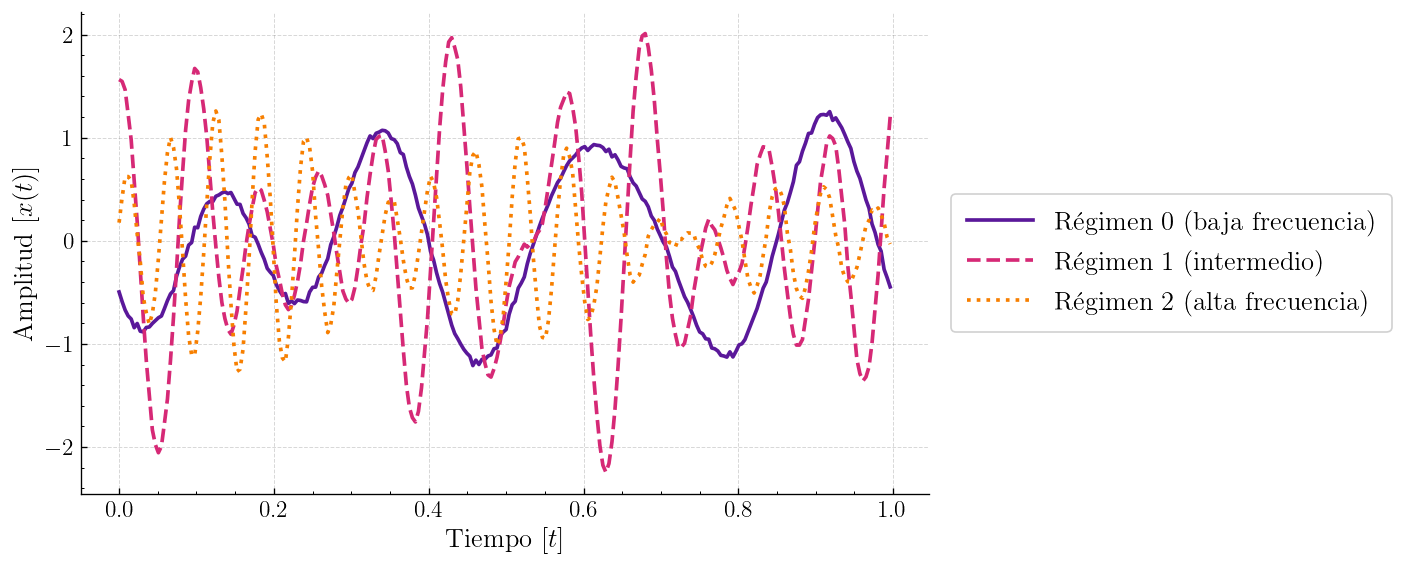

In [5]:
# Selección de una señal por régimen
idx0 = np.where(y == 0)[0][0]
idx1 = np.where(y == 1)[0][0]
idx2 = np.where(y == 2)[0][0]

x0 = X[idx0]
x1 = X[idx1]
x2 = X[idx2]

# Paleta violeta / magent / naranja / tonos que se me parecen a magma
colores = ["#5A189A", "#D62976", "#F77F00"]
estilos = ["-", "--", ":"]  # sólido-guiones-puntos
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t, x0, label="Régimen 0 (baja frecuencia)",
        color=colores[0], linestyle=estilos[0], linewidth=2.2)
ax.plot(t, x1, label="Régimen 1 (intermedio)",
        color=colores[1], linestyle=estilos[1], linewidth=2.2)
ax.plot(t, x2, label="Régimen 2 (alta frecuencia)",
        color=colores[2], linestyle=estilos[2], linewidth=2.2)

ax.set_xlabel(r"Tiempo $[t]$")
ax.set_ylabel(r"Amplitud $[x(t)]$")

ax.grid(True, alpha=0.3, linewidth=0.6)

# Leyenda
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 0.65),
    frameon=True,
    framealpha=0.9,
    borderpad=0.6,
    handlelength=2.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# **1. Capa Fourier ⚛**

Se construye una matriz $W_1$ cuyas filas corresponden a funciones
seno y coseno de distintas frecuencias.

Esta matriz permitirá proyectar las señales al dominio de frecuencias.

In [6]:
def construir_W1(K, t):
    N = len(t)
    dt = t[1] - t[0]
    T = N * dt

    filas = []
    for k in range(1, K + 1):
        filas.append(jnp.sin(2 * np.pi * k * t / T))
        filas.append(jnp.cos(2 * np.pi * k * t / T))

    W1 = jnp.array(filas)
    return W1, T

# Construcción
K = 25
W1, T = construir_W1(K, t)
print("Dimensión de W1:", W1.shape) #(2k, N)

Dimensión de W1: (50, 256)


La matriz $W_1$ representa una base de Fourier discreta truncada. Al multiplicar $W1$ @ $x$ se proyecta la señal $x$ sobre senos y cosenos de distintas frecuencias lo cual produce coeficientes similares a los de la transformada de Fourier, pero en forma real (no compleja). En este caso, las filas seno capturan la parte imaginaria; mientras que, las filas coseno capturan la parte real.

Solo se usan $K$ frecuencias, por ello se está aproximando la FFT usando bajas frecuencias. Para verificar que la matriz $ W_1 $ captura el contenido frecuencial de las señales se compara su proyección con la Transformada de Fourier obtenida mediante `np.fft.fft`. Esta función recibe como entrada las $N$ muestras de una señal en el tiempo y su salida son los $N$ coeficientes complejos cada uno asociados a una frecuencia.

Además, la FFT se aplica tanto a una señal como a varias a la vez. Por defecto actúa sobre el último eje del arreglo así que si X tiene forma (n_señales, N), se calcula la FFT de todas las señales a la vez sin requerir un bucle.

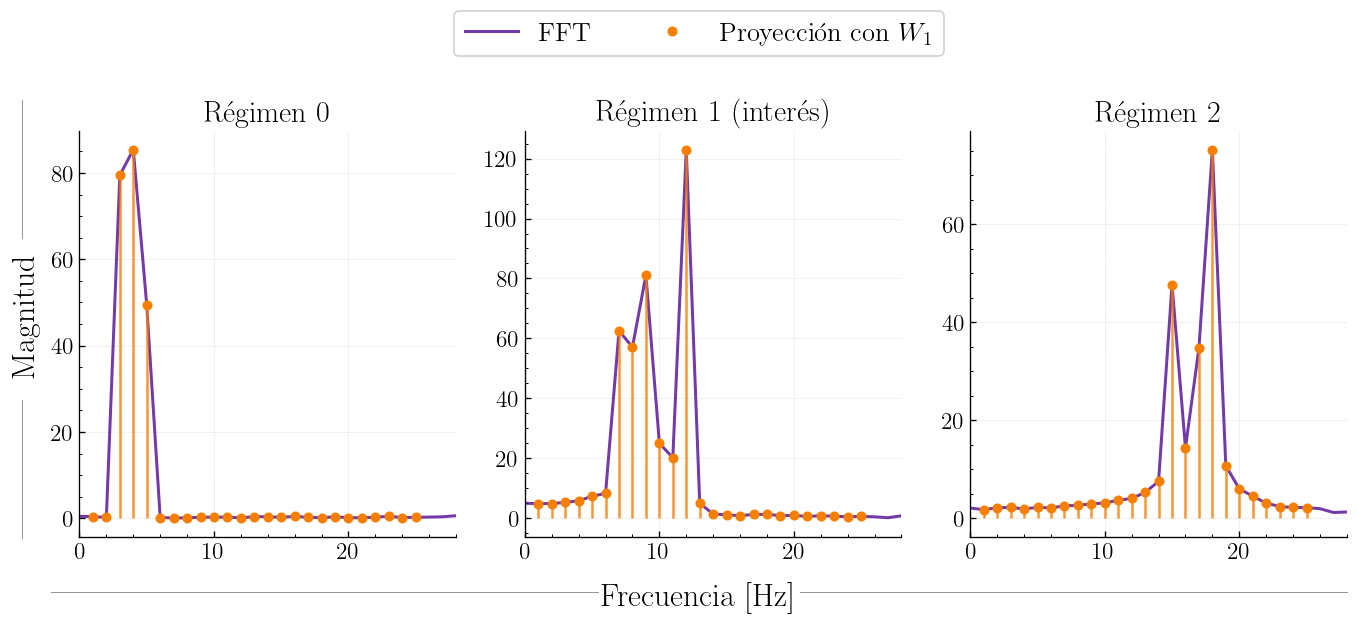

In [7]:
# señal representativa por régimen
indices = [np.where(y == i)[0][0] for i in range(3)]
regimenes = [0, 1, 2]
dt = t[1] - t[0]

#frecuencias reales (FFT)
freqs = np.fft.fftfreq(len(t), d=dt)
mask = freqs >= 0

# frecuencias usadas por W1 (indice k)
freqs_k = np.arange(1, K + 1) / T

color_fft = "#5A189A"
color_w1  = "#F77F00"

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, idx, regimen in zip(axes, indices, regimenes):
    x = X[idx]

    # Proyección con W1 y su magnitud
    proj_W1 = W1 @ jnp.array(x)

    # magnitud combinando seno y coseno
    proj_mag = np.sqrt(np.array(proj_W1[0::2])**2 + np.array(proj_W1[1::2])**2)

    # FFT de referencia
    fft_mag = np.abs(np.fft.fft(x))

    # Curva FFT
    ax.plot(freqs[mask], fft_mag[mask], label="FFT",
            color=color_fft, linewidth=1.8, alpha=0.85)

    # Proyección W1
    markerline, stemlines, _ = ax.stem(freqs_k, proj_mag, basefmt=" ")
    markerline.set_color(color_w1)
    markerline.set_markersize(5)
    stemlines.set_color(color_w1)
    stemlines.set_alpha(0.8)
    markerline.set_label(r"Proyección con $W_1$")

    # Configuración de cada panel
    ax.set_title(f"Régimen {regimen}" + (" (interés)" if regimen == 1 else ""))
    ax.set_xlim(0, K / T + 3)
    ax.grid(True)

plt.tight_layout(rect=[0.06, 0.06, 1, 0.93])
fig.supxlabel("Frecuencia [Hz]", x=0.53, y=0.025)
fig.supylabel("Magnitud", x=0.053, y=0.52)

# Leyenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.53, 1.05),
           ncol=2, frameon=True, framealpha=0.9)

color_linea = "gray"
lw_linea = 0.5

#Líneas para ser más explíicitas con los ejes
fig.add_artist(plt.Line2D([0.06, 0.06], [0.65, 0.88],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.06, 0.06], [0.15, 0.38],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))

fig.add_artist(plt.Line2D([0.08, 0.46], [0.06, 0.06],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))
fig.add_artist(plt.Line2D([0.6, 0.98], [0.06, 0.06],
                           color=color_linea, linewidth=lw_linea,
                           transform=fig.transFigure))

plt.show()

Los picos de la proyección con $W_1$ coinciden en frecuencia y magnitud
con los picos de la FFT, lo cual confirma que $W_1$ reproduce la transformada de Fourier discreta desde su inicialización. En el régimen de interés (régimen 1) se observan dos modos dominantes: uno en 8 Hz con magnitud aproximadamente de 60 y otro en 12 Hz con magnitud aproximadamente de 80, siendo este último el de mayor energía. Ello indica que la dinámica del régimen 1 está concentrada en un rango de frecuencias medias-altas y dominado por el componente de 12 Hz.

**Energía media**

Para responder a la pregunta: ¿qué tan "fuerte" es cada señal? Se remite al concepto de *energía* y es simplemente la suma de los valores de la señal al cuadrado: $E = \sum_n x_n^2$

Si en vez de la suma total se toma el promedio, entonces se obtiene **energía media**: $\bar E = \frac{1}{N}\sum_n x_n^2$.

Lo interesante es que la misma energía se puede calcular de dos maneras distintas y da casi el mismo número: sumando la señal en el tiempo, como lo anterior, o sumando sus componentes de frecuencia (los coeficientes de Fourier). A eso se le conoce como **teorema de Parseval**: $\sum_{n} x_n^2 = \frac{1}{N}\sum_k |X_k|^2$.

Así, no importa si se mira la señal "en el tiempo" o "en frecuencia", la energía que contiene es la misma. Esto es demasiado útil porque si se quisiera quedar solo con algunas frecuencias (las más importantes) en vez de con la señal completa se podría usar la energía para saber qué tanto se pierde sin tener que reconstruir la señal cada vez para comparar.

In [8]:
energia_media = (X**2).mean()

print(f"Energía media: {energia_media:.3f}")

Energía media: 0.678


# **2. Entrenamiento y reconstrucción** ⚛


Se implementa la red neuronal que reconstruye las señales. La arquitectura corresponde a un modelo de dos capas:

$
\hat{x} = W_2, \tanh(W_1 x)
$

Se consideran dos inicializaciones para $W_1$:

- Inicialización Fourier
- Inicialización aleatoria

In [9]:
#Inicialización aleatoria
#Se usa una única key base (6767) y se divide en 3 sub-keys independientes:
# una para split train val, otra para inicializar w1 aleatorio y otra para w2.
key = jax.random.PRNGKey(6767)
key_split_val, key_w1_rand, key_w2 = jax.random.split(key, 3)

def split_train_val(X, y, key, val_frac=0.2):
    #Separa índices del dataset en entrenamiento y validación con 20% de cada regimen
    # para garantizar que los 3 queden representados en ambos conjuntos,
    # aun con pocas señales por régimen.
    idx_train, idx_val = [], []
    k = key
    for r in np.unique(np.array(y)):
        idx_r = np.where(np.array(y) == r)[0]
        k, subkey = jax.random.split(k)
        perm = np.array(jax.random.permutation(subkey, len(idx_r)))
        idx_r = idx_r[perm]
        n_val = max(1, int(len(idx_r) * val_frac))
        idx_val.extend(idx_r[:n_val])
        idx_train.extend(idx_r[n_val:])
    return np.array(idx_train), np.array(idx_val)

idx_train, idx_val = split_train_val(X, y, key_split_val, val_frac=0.2)
X_train_jax = jnp.array(X[idx_train])
print(f"Entrenamiento: {len(idx_train)} señales | Validación: {len(idx_val)} señales")


Entrenamiento: 21 señales | Validación: 3 señales


**Observación.** Lo anterior tiene sentido pues con 10 señales por régimen, el 20% da 2 de validación y 8 de entrenamiento por cada régimen. Por los 3 regímenes serían: 6 y 24, en total 30, que es lo esperado según datos personalizados.

In [10]:
# W1_fourier viene de la capa de Fourier construida en la Parte 1 (senos/cosenos).
# W2_init se genera UNA sola vez y se usa igual en ambas inicializaciones
# para que la única variable que cambie entre experimentos sea el punto de partida de W1.

W1_fourier = jnp.array(W1)
W2_init = jax.random.normal(key_w2, (256, 2*K)) * 0.1

def init_fourier_params():
  return {"W1": W1_fourier, "W2": W2_init}

def init_random_params(key_w1_rand):
  W1 = jax.random.normal(key_w1_rand, (2*K, 256)) * 0.1
  return {"W1": W1, "W2": W2_init}

La red se entrena minimizando el error cuadrático medio entre la señal original y su reconstrucción:

$
\mathcal{L} = \frac{1}{N} | \hat{x} - x |^2
$.
Esta función mide qué tan bien la red logra reconstruir las señales del dataset.

In [11]:
#Arquitectura y función de pérdida

#Forward
def forward(params, x):
    # x_hat = W2 · tanh(W1 · x) — la arquitectura de dos capas del enunciado
    W1, W2 = params["W1"], params["W2"]
    return W2 @ jnp.tanh(W1 @ x)

#Funcion perdida
def loss_fn(params, x):
    # MSE de una señal: (1/N) * ||x_hat - x||^2
    x_hat = forward(params, x)
    return jnp.mean((x_hat - x)**2)

#Pérdida de todo el dataset
def dataset_loss(params, X):
    # Promedia la pérdida individual sobre todas las señales del batch
    return jnp.mean(jax.vmap(lambda x: loss_fn(params, x))(X))

In [12]:
#Entrenamiento por descenso de gradiente
lr = 0.05 #learning rate sugerido
n_iters = 3000 #iteraciones

@jit
def update(params, X):
    #un paso de descenso de gradiente sobre todos los parámetros
    grads = jax.grad(dataset_loss)(params, X)

    return {
        "W1": params["W1"] - lr * grads["W1"],
        "W2": params["W2"] - lr * grads["W2"]
    }

#Entrenamiento
def train(params, X, n_iters):
    #Entrena 3000 pasos, guarda la perdida cada 10 iteraciones
    losses = []

    for i in range(n_iters):
        params = update(params, X)

        if i % 10 == 0:
          losses.append(dataset_loss(params, X / energia_media))
    return params, jnp.array(losses)

#Inicializar y entrenar
params_fourier = init_fourier_params()
params_random = init_random_params(key_w1_rand)

# Se entrena solamente con X_train_jax (nunca con validación) —
# esto es lo que hace que el error en validación sea una medida
# honesta de generalización y no de memorización.

params_fourier, losses_fourier = train(params_fourier, X_train_jax, n_iters)
params_random, losses_random = train(params_random, X_train_jax, n_iters)


In [13]:
#Reconstrucción y error relativo
#Función para reconstrucción
def reconstruir(params, x):
    # Pasa una señal x por la red entrenada y devuelve la reconstrucción
    return np.array(forward(params, jnp.array(x)))

#Error relativo $\frac{| \hat{x} - x |}{| x |}$
def error_relativo(x, x_hat):
    # mide qué tan grande es el error de reconstrucción en proporción a la magnitud de la señal original.
    # Un valor de 1.0 significa que el error es tan grande como la señal misma;
    # equivalente, en magnitud, a "no reconstruir nada".
    return np.linalg.norm(x_hat - x) / np.linalg.norm(x)

#selección de nuevo de la señal por regimen
idx0 = idx_val[y[idx_val] == 0][0]
idx1 = idx_val[y[idx_val] == 1][0]
idx2 = idx_val[y[idx_val] == 2][0]

x0, x1, x2 = X[idx0], X[idx1], X[idx2]

#Reconstrucciones
x0_f, x1_f, x2_f = (reconstruir(params_fourier, x) for x in (x0, x1, x2))
x0_r, x1_r, x2_r = (reconstruir(params_random, x) for x in (x0, x1, x2))

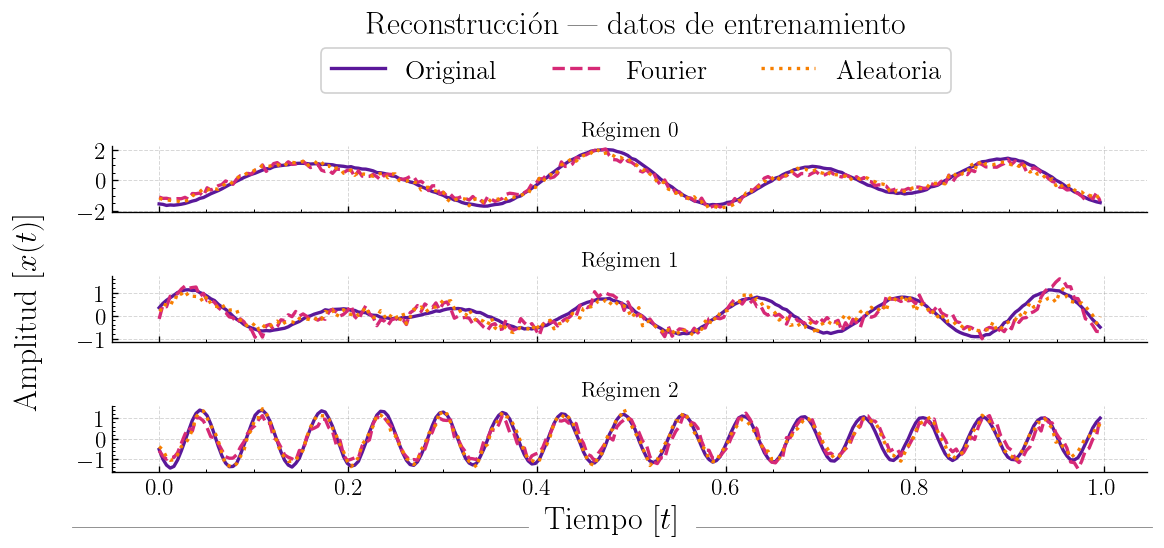

In [14]:
colores = ["#5A189A", "#D62976", "#F77F00"]
estilos = ["-", "--", ":"]

def graficar_reconstruccion(idxs, titulo_extra, filename_tag):
    #Grafica original vs Fourier vs Aleatoria, una señal por régimen,
    # tomando los índices del conjunto indicado (train o val)."""
    idx0 = idxs[y[idxs] == 0][0]
    idx1 = idxs[y[idxs] == 1][0]
    idx2 = idxs[y[idxs] == 2][0]
    x0, x1, x2 = X[idx0], X[idx1], X[idx2]

    x0_f, x1_f, x2_f = (reconstruir(params_fourier, x) for x in (x0, x1, x2))
    x0_r, x1_r, x2_r = (reconstruir(params_random, x) for x in (x0, x1, x2))

    regimenes = [(x0, x0_f, x0_r, "Régimen 0"),
                 (x1, x1_f, x1_r, "Régimen 1"),
                 (x2, x2_f, x2_r, "Régimen 2")]

    fig, axs = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
    for ax, (x, xf, xr, tit) in zip(axs, regimenes):
        ax.plot(t, x,  label="Original",  color=colores[0], linestyle=estilos[0], linewidth=2.0)
        ax.plot(t, xf, label="Fourier",   color=colores[1], linestyle=estilos[1], linewidth=2.0)
        ax.plot(t, xr, label="Aleatoria", color=colores[2], linestyle=estilos[2], linewidth=2.0)
        ax.set_title(tit, fontsize=13)
        ax.grid(True, alpha=0.3, linewidth=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Reconstrucción — {titulo_extra}", x = 0.55, y=0.9)
    plt.tight_layout(rect=[0.06, 0.04, 1, 0.86])
    fig.supxlabel(r"Tiempo $[t]$", x=0.53, y=0.025)
    fig.supylabel(r"Amplitud $[x(t)]$", x=0.03, y=0.4)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.55, 0.86),
               ncol=3, frameon=True, framealpha=0.9)

        #Líneas para el eje y
    fig.add_artist(plt.Line2D([0.08, 0.46], [0.04, 0.04],
                              color=color_linea, linewidth=lw_linea,
                              transform=fig.transFigure))
    fig.add_artist(plt.Line2D([0.6, 0.98], [0.04, 0.04],
                              color=color_linea, linewidth=lw_linea,
                              transform=fig.transFigure))
    plt.show()
    return idx0, idx1, idx2

# ENTRENAMIENTO
# Sirve como referencia de "ajuste" (qué tanto la red logró aprender
# de los datos que sí usó). Se espera que se vea razonablemente bien.
idx0_tr, idx1_tr, idx2_tr = graficar_reconstruccion(idx_train, "datos de entrenamiento", "train")

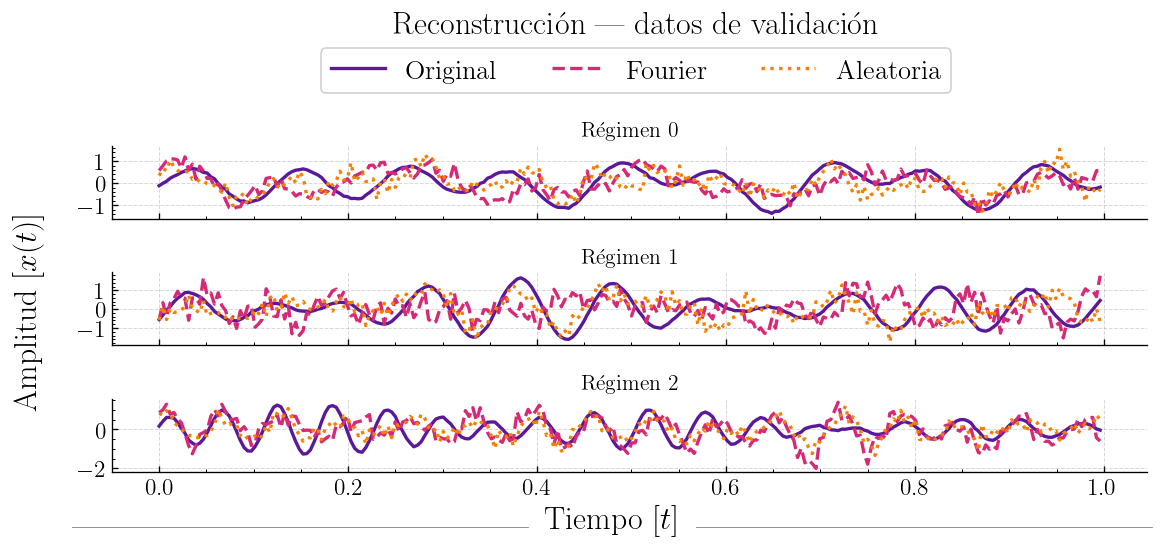

In [15]:
# VALIDACIÓN
# mide generalización real, con señales que la red nunca vio durante el entrenamiento.
idx0, idx1, idx2 = graficar_reconstruccion(idx_val, "datos de validación", "val")

In [16]:
def error_por_regimen(params, idxs):
    errores = {}
    for r in [0, 1, 2]:
        idx_r = idxs[y[idxs] == r]
        vals = [error_relativo(X[i], reconstruir(params, X[i])) for i in idx_r]
        errores[r] = np.mean(vals)
    return errores

def error_promedio(params, idxs):
    # Calcula el error promedio sobre un conjunto de índices (sin separar por régimen)
    # Aplica reconstrucción y error relativo a cada muestra
    # Retorna el promedio global
    errores = [error_relativo(X[i], reconstruir(params, X[i])) for i in idxs]
    return np.mean(errores)

# Calcula errores por régimen para Fourier y Aleatoria en train y validación
err_f_train = error_por_regimen(params_fourier, idx_train)
err_r_train = error_por_regimen(params_random, idx_train)
err_f_val   = error_por_regimen(params_fourier, idx_val)
err_r_val   = error_por_regimen(params_random, idx_val)

print("Error relativo promedio por régimen:\n")
print(f"{'Régimen':<10}{'Fourier (train)':<18}{'Aleatoria (train)':<20}{'Fourier (val)':<16}{'Aleatoria (val)'}")
for r in [0, 1, 2]:
    print(f"{r:<10}{err_f_train[r]:<18.4f}{err_r_train[r]:<20.4f}{err_f_val[r]:<16.4f}{err_r_val[r]:.4f}")

print("\nError relativo promedio (global):")
print(f"  Entrenamiento -> Fourier: {error_promedio(params_fourier, idx_train):.4f} | Aleatoria: {error_promedio(params_random, idx_train):.4f}")
print(f"  Validación    -> Fourier: {error_promedio(params_fourier, idx_val):.4f} | Aleatoria: {error_promedio(params_random, idx_val):.4f}")

Error relativo promedio por régimen:

Régimen   Fourier (train)   Aleatoria (train)   Fourier (val)   Aleatoria (val)
0         0.2568            0.2602              1.0033          0.9281
1         0.3449            0.3312              1.3294          0.9575
2         0.3410            0.3101              1.3295          1.0085

Error relativo promedio (global):
  Entrenamiento -> Fourier: 0.3142 | Aleatoria: 0.3005
  Validación    -> Fourier: 1.2208 | Aleatoria: 0.9647


**Interpretación.** El error relativo en validación es mayor que el de entrenamiento en ambas inicializaciones, es por esto que el modelo ajusta bien los datos vistos pero generaliza mal a señales nuevas.

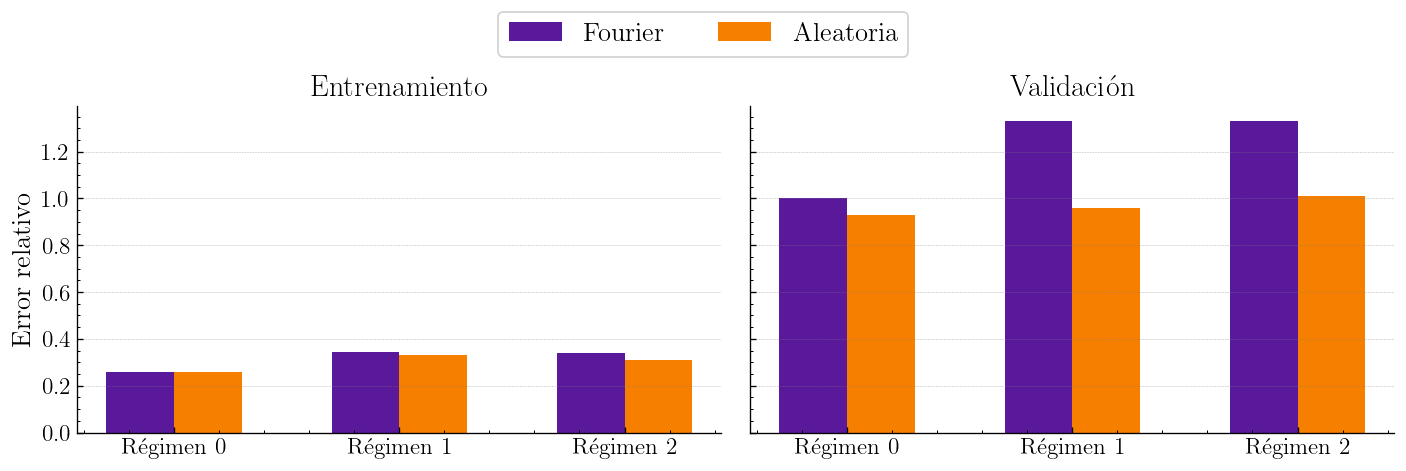

In [17]:
nombres_regimen = ["Régimen 0", "Régimen 1", "Régimen 2"]
xpos = np.arange(3)
width = 0.3

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axs[0].bar(xpos - width/2, [err_f_train[r] for r in [0,1,2]], width, label="Fourier", color=colores[0])
axs[0].bar(xpos + width/2, [err_r_train[r] for r in [0,1,2]], width, label="Aleatoria", color=colores[2])
axs[0].set_title("Entrenamiento")
axs[0].set_xticks(xpos)
axs[0].set_xticklabels(nombres_regimen)
axs[0].set_ylabel("Error relativo")
axs[0].grid(axis='y', linestyle='--', alpha=0.6)

axs[1].bar(xpos - width/2, [err_f_val[r] for r in [0,1,2]], width, label="Fourier", color=colores[0])
axs[1].bar(xpos + width/2, [err_r_val[r] for r in [0,1,2]], width, label="Aleatoria", color=colores[2])
axs[1].set_title("Validación")
axs[1].set_xticks(xpos)
axs[1].set_xticklabels(nombres_regimen)
axs[1].grid(axis='y', linestyle='--', alpha=0.6)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Interpretación.** Los resultados muestran que ambas parametrizaciones logran errores similares en entrenamiento, lo que indica que ambas son capaces de ajustar los datos observados. La parametrización aleatoria presenta consistentemente menores errores relativos de reconstrucción en comparación con la parametrización de Fourier, tanto en entrenamiento como en validación. Sin embargo, la diferencia es más marcada en validación, lo que indica que la parametrización de Fourier presenta mayor sobreajuste y menor capacidad de generalización. Por el contrario, la parametrización aleatoria mantiene errores más bajos y estables, lo que indica una mejor capacidad de generalización.

En conclusión, aunque la parametrización de Fourier puede capturar adecuadamente ciertas estructuras en entrenamiento, la parametrización aleatoria resulta más robusta y efectiva para reconstruir datos no vistos.

# **3. Comparación de inicializaciones ⚛**

/var/folders/_0/x27k___j503f9q5kp6nfb9kw0000gn/T/ipykernel_53634/2432728562.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 3000)


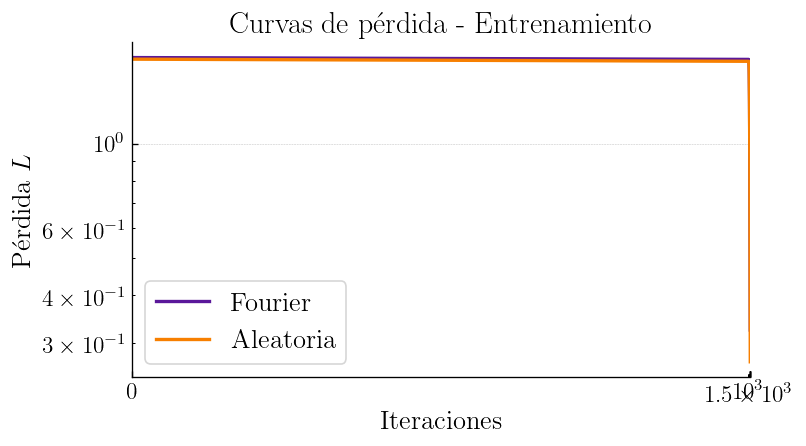

In [24]:
def suaviza(v, w=15):
    # Promedio móvil simple para quitar el ruido punto a punto de la
    # curva y ver mejor la tendencia general
    p = w // 2
    vp = np.pad(v, (p, p), mode="edge")
    return np.convolve(vp, np.ones(w)/w, mode="valid")[:len(v)]

iters = np.arange(0, n_iters, 10)

loss_f_suave = suaviza(losses_fourier)
loss_r_suave = suaviza(losses_random)

plt.figure(figsize=(7,4))

plt.loglog(iters, loss_f_suave, label="Fourier", color=colores[0], lw=2)
plt.loglog(iters, loss_r_suave, label="Aleatoria", color=colores[2], lw=2)

plt.xlabel("Iteraciones")
plt.ylabel("Pérdida $L$")
plt.title("Curvas de pérdida - Entrenamiento")

plt.xlim(0, 3000)
plt.xticks(np.arange(0, 3001, 500))

plt.legend()
plt.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Interpretación.** En ambos casos, la pérdida decrece de manera suave y monótona, lo que indica un proceso de aprendizaje estable. Se observa que la inicialización aleatoria presenta un mejor desempeño en todo momento y mantiene una pérdida inferior a la inicialización de Fourier a lo largo de todas las iteraciones. Así, en este caso, la inicialización aleatoria permite una mejor adaptación de los parámetros del modelo.

In [19]:
def iteracion_umbral(losses, iters, umbral=0.1):
    # Busca la primera iteración donde la pérdida baja de un umbral
    # Si no se alcanza, devuelve None
    for l, it in zip(losses, iters):
        if l < umbral:
            return it
    return None

#  pérdidas de TRAIN
it_f_01 = iteracion_umbral(loss_f_suave, iters)
it_r_01 = iteracion_umbral(loss_r_suave, iters)

print("Iteraciones hasta error relativo < 0.1 (train):")
print(f"Fourier:   {it_f_01 if it_f_01 is not None else 'No se alcanza en 3000 iteraciones'}")
print(f"Aleatoria: {it_r_01 if it_r_01 is not None else 'No se alcanza en 3000 iteraciones'}")

print("\nError relativo mínimo alcanzado (train):")
print(f"  Fourier:   {np.min(loss_f_suave):.4f}")
print(f"  Aleatoria: {np.min(loss_r_suave):.4f}")

Iteraciones hasta error relativo < 0.1 (train):
Fourier:   No se alcanza en 3000 iteraciones
Aleatoria: No se alcanza en 3000 iteraciones

Error relativo mínimo alcanzado (train):
  Fourier:   0.3179
  Aleatoria: 0.2870


En entrenamiento ninguna alcanza $0.1$; en validación se observa un comportamiento similar como se abordará a continuación.

In [20]:
def dict_to_array(err_dict):
    # Convierte diccionario de errores en array
    # Calcula promedio (por si hay múltiples valores)
    arr = np.array(list(err_dict.values()))
    return np.mean(arr, axis=0)

err_f_val_array = dict_to_array(err_f_val)
err_r_val_array = dict_to_array(err_r_val)

threshold = 0.1

def iter_to_threshold(errors, threshold):
    # Encuentra la primera posición donde el error es menor al umbral
    # Devuelve número de iteración (índice + 1)
    errors = np.atleast_1d(errors)
    indices = np.where(errors < threshold)[0]
    return indices[0] + 1 if len(indices) > 0 else None

iter_f_val = iter_to_threshold(err_f_val_array, threshold)
iter_r_val = iter_to_threshold(err_r_val_array, threshold)

min_f_val = np.min(err_f_val_array)
min_r_val = np.min(err_r_val_array)

print("Iteraciones hasta error relativo < 0.1 (validación):")
print(f"Fourier:   {iter_f_val if iter_f_val else 'No se alcanza en 3000 iteraciones'}")
print(f"Aleatoria: {iter_r_val if iter_r_val else 'No se alcanza en 3000 iteraciones'}")

print("\nError relativo mínimo alcanzado (validación):")
print(f"  Fourier:   {min_f_val:.4f}")
print(f"  Aleatoria: {min_r_val:.4f}")

Iteraciones hasta error relativo < 0.1 (validación):
Fourier:   No se alcanza en 3000 iteraciones
Aleatoria: No se alcanza en 3000 iteraciones

Error relativo mínimo alcanzado (validación):
  Fourier:   1.2208
  Aleatoria: 0.9647


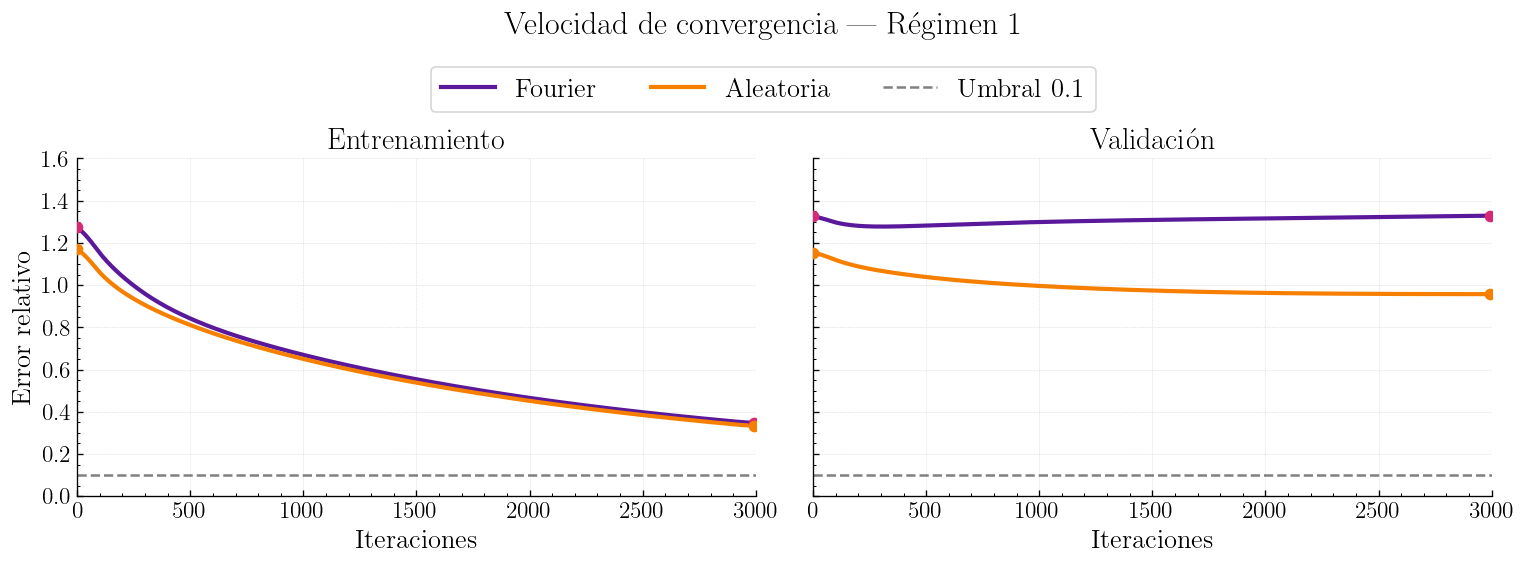

Régimen 1 — iteraciones hasta error relativo < 0.1:

Entrenamiento:
  Fourier:   No se alcanza en 3000 iteraciones
  Aleatoria: No se alcanza en 3000 iteraciones

Validación:
  Fourier:   No se alcanza en 3000 iteraciones
  Aleatoria: No se alcanza en 3000 iteraciones


In [21]:
def suaviza(v, w=15):
    # Promedio móvil simple para quitar el ruido punto a punto de la
    # curva de error y ver mejor la tendencia general
    p = w // 2
    vp = np.pad(v, (p, p), mode="edge")
    return np.convolve(vp, np.ones(w)/w, mode="valid")[:len(v)]

def error_regimen(params, idxs, regime):
    # Calcula el error promedio separando por cada régimen (0, 1, 2)
    # Filtra los índices que pertenecen a cada régimen
    # Calcula el error relativo de cada señal reconstruida
    # Guarda el promedio de error por régimen en un diccionario
    idx_r = idxs[y[idxs] == regime]
    vals = [error_relativo(X[i], reconstruir(params, X[i])) for i in idx_r]
    return np.mean(vals)

def train_regimen(params, X_train, idxs_eval, regime, n_iters):
    # Entrena con los datos de entrenamiento de siempre, y cada 10
    # iteraciones evalúa el error sobre el conjunto indicado (train o val)
    # para el régimen dado
    errores = []
    iters = []
    for i in range(n_iters):
        params = update(params, X_train)
        if i % 10 == 0:
            err = error_regimen(params, idxs_eval, regime)
            errores.append(err)
            iters.append(i + 1)
    return params, np.array(iters), np.array(errores)

def iter_hasta_umbral(iters, errores, umbral=0.1):
    # Devuelve la iteración donde el error baja del umbral
    # Si no pasa, devuelve None
    idx = np.where(errores < umbral)[0]
    return int(iters[idx[0]]) if len(idx) > 0 else None

# Entrenamiento de las 4 curvas: Fourier/Aleatoria x train/val
params_f = init_fourier_params()
params_r = init_random_params(key_w1_rand)
params_f_tr, it_f_tr, err_f_tr = train_regimen(params_f, X_train_jax, idx_train, regime=1, n_iters=n_iters)
params_r_tr, it_r_tr, err_r_tr = train_regimen(params_r, X_train_jax, idx_train, regime=1, n_iters=n_iters)

params_f = init_fourier_params()
params_r = init_random_params(key_w1_rand)
params_f_val, it_f_val, err_f_val = train_regimen(params_f, X_train_jax, idx_val, regime=1, n_iters=n_iters)
params_r_val, it_r_val, err_r_val = train_regimen(params_r, X_train_jax, idx_val, regime=1, n_iters=n_iters)

err_f_tr_s, err_r_tr_s = suaviza(err_f_tr), suaviza(err_r_tr)
err_f_val_s, err_r_val_s = suaviza(err_f_val), suaviza(err_r_val)

# Figura con ambos paneles: entrenamiento y validación
fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

paneles = [
    (axs[0], it_f_tr, err_f_tr_s, it_r_tr, err_r_tr_s, "Entrenamiento"),
    (axs[1], it_f_val, err_f_val_s, it_r_val, err_r_val_s, "Validación"),
]

for ax, itf, errf, itr, errr, subtitulo in paneles:
    ax.plot(itf, errf, label="Fourier", color=colores[0], linewidth=2.5)
    ax.plot(itr, errr, label="Aleatoria", color=colores[2], linewidth=2.5)
    ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.5, label="Umbral 0.1")

    ax.scatter([itf[0], itf[-1]], [errf[0], errf[-1]], color=colores[1], zorder=3)
    ax.scatter([itr[0], itr[-1]], [errr[0], errr[-1]], color=colores[2], zorder=3)

    ax.set_xlabel("Iteraciones")
    ax.set_title(subtitulo)
    ax.set_xlim(0, n_iters)
    ax.set_xticks(np.arange(0, n_iters + 1, 500))
    ax.grid(True, linestyle="--", alpha=0.3)

axs[0].set_ylabel("Error relativo")
y_max = max(err_f_tr_s.max(), err_r_tr_s.max(), err_f_val_s.max(), err_r_val_s.max())
axs[0].set_ylim(0, y_max + 0.15)
axs[0].set_yticks(np.arange(0, y_max + 0.3, 0.2))

fig.suptitle("Velocidad de convergencia — Régimen 1", y=0.95)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=3, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

# Iteraciones hasta cruzar el umbral
print("Régimen 1 — iteraciones hasta error relativo < 0.1:\n")
print("Entrenamiento:")
print(f"  Fourier:   {iter_hasta_umbral(it_f_tr, err_f_tr_s) or 'No se alcanza en 3000 iteraciones'}")
print(f"  Aleatoria: {iter_hasta_umbral(it_r_tr, err_r_tr_s) or 'No se alcanza en 3000 iteraciones'}")
print("\nValidación:")
print(f"  Fourier:   {iter_hasta_umbral(it_f_val, err_f_val_s) or 'No se alcanza en 3000 iteraciones'}")
print(f"  Aleatoria: {iter_hasta_umbral(it_r_val, err_r_val_s) or 'No se alcanza en 3000 iteraciones'}")

**Interpretación.**
La gráfica muestra que bajo criterio de error relativo $< 0.1$, ninguno de los métodos, ni la inicialización en base de Fourier ni la inicialización aleatoria, logra converger dentro del límite de 3000 iteraciones, tanto en entrenamiento como en validación. Esto indica que el algoritmo no es capaz de reducir el error de reconstrucción a un nivel suficientemente bajo en este régimen, lo que sugiere que los parámetros no son adecuados para alcanzar dicha precisión.

# **4. Compresión ⚛**

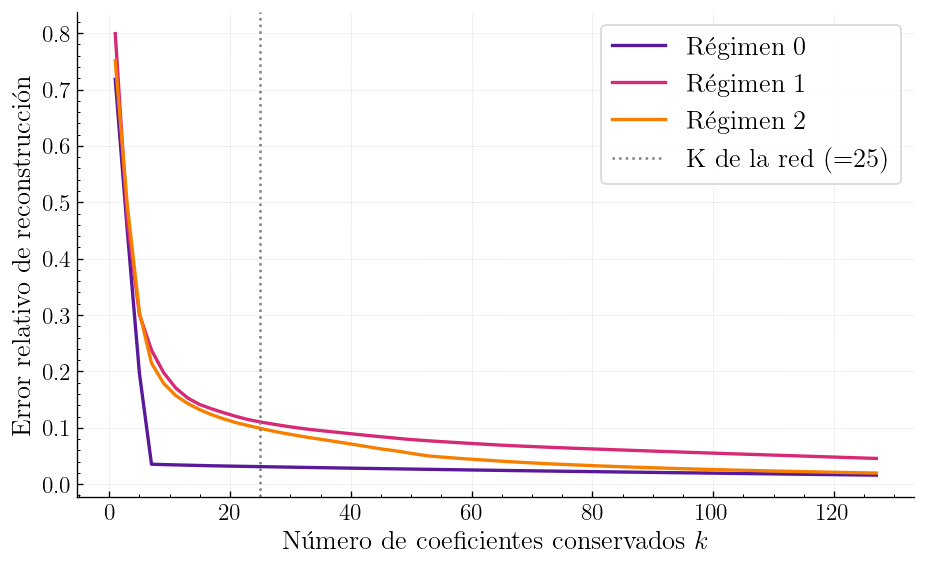

In [22]:
# Reconstrucción truncada: conservar solo los k coeficientes
#    de mayor magnitud de la FFT, y reconstruir con ifft
def reconstruccion_top_k(x, k):
    # FFT completa de la señal
    X_fft = np.fft.fft(x)

    # Índices de los k coeficientes de mayor magnitud (conservando
    # también su conjugado, ya que la señal es real y el espectro
    # es simétrico: si me quedo con la frecuencia f, debo quedarme
    # también con -f para que la señal reconstruida sea real)
    idx_top = np.argsort(np.abs(X_fft))[::-1][:k]

    X_fft_trunc = np.zeros_like(X_fft)
    X_fft_trunc[idx_top] = X_fft[idx_top]

    x_rec = np.fft.ifft(X_fft_trunc).real
    return x_rec

# Error de reconstrucción vs número de coeficientes conservados
N = len(t)
k_values = np.arange(1, N // 2 + 1, 2)

def error_vs_k(x, k_values):
    return np.array([error_relativo(x, reconstruccion_top_k(x, k)) for k in k_values])

# Señal representativa por régimen (usamos la misma selección de
# validación que en las secciones anteriores, para mantener coherencia)
x0, x1, x2 = X[idx0], X[idx1], X[idx2]

err_k_0 = error_vs_k(x0, k_values)
err_k_1 = error_vs_k(x1, k_values)
err_k_2 = error_vs_k(x2, k_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, err_k_0, color=colores[0], linewidth=2, label="Régimen 0")
ax.plot(k_values, err_k_1, color=colores[1], linewidth=2, label="Régimen 1")
ax.plot(k_values, err_k_2, color=colores[2], linewidth=2, label="Régimen 2")

ax.axvline(K, color="gray", linestyle=":", linewidth=1.5, label=f"K de la red (={K})")

ax.set_xlabel(r"Número de coeficientes conservados $k$")
ax.set_ylabel("Error relativo de reconstrucción")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La tres caen muy rápido en los primeros 10 coeficientes aproximadamente y luego aplana, lo que revela una compresión eficiente por Fourier. Pero se nota una diferencia: en régimen 0 y 2 caen casi juntas y rápido pero el régimen 1 (el de interés) decae más lento y se queda encima de las otras dos en todo el rango.

La línea vertical en K=15 cae justo en la zona donde régimen 0 y 2 ya prácticamente convergieron a su error mínimo, pero régimen 1 todavía está en la parte empinada de la curva.

In [23]:
# Coeficientes necesarios para alcanzar el criterio de energía (85%)
def k_para_energia(x, umbral=0.85):
    X_fft = np.fft.fft(x)
    energia = np.abs(X_fft) ** 2
    energia_ordenada = np.sort(energia)[::-1]  # de mayor a menor
    energia_acumulada = np.cumsum(energia_ordenada)
    energia_total = energia_acumulada[-1]

    # Primer k donde la energía acumulada alcanza el umbral
    k_min = np.searchsorted(energia_acumulada / energia_total, umbral) + 1
    return k_min

umbral_energia = 0.90  # criterio de compresión personalizado (ref)

k0 = k_para_energia(x0, umbral_energia)
k1 = k_para_energia(x1, umbral_energia)
k2 = k_para_energia(x2, umbral_energia)

print(f"Coeficientes necesarios para alcanzar {umbral_energia*100:.0f}% de la energía:")
print(f"  Régimen 0: {k0}")
print(f"  Régimen 1 (interés): {k1}")
print(f"  Régimen 2: {k2}")

# Promedio sobre todas las señales de cada régimen (no solo la representativa),
# para tener un número más robusto que el de una sola señal
def k_promedio_por_regimen(X, y, regime, umbral=0.85):
    idx_r = np.where(y == regime)[0]
    ks = [k_para_energia(X[i], umbral) for i in idx_r]
    return np.mean(ks), np.std(ks)

for r in [0, 1, 2]:
    k_prom, k_std = k_promedio_por_regimen(X, y, r, umbral_energia)
    print(f"Régimen {r}: k promedio = {k_prom:.1f} ± {k_std:.1f} (sobre todas las señales del régimen)")

Coeficientes necesarios para alcanzar 90% de la energía:
  Régimen 0: 5
  Régimen 1 (interés): 5
  Régimen 2: 6
Régimen 0: k promedio = 5.6 ± 0.5 (sobre todas las señales del régimen)
Régimen 1: k promedio = 7.9 ± 3.3 (sobre todas las señales del régimen)
Régimen 2: k promedio = 6.1 ± 0.8 (sobre todas las señales del régimen)


**Interpretación.**  Régimen 1 necesita más coeficientes que los otros dos, de igual manera, requiere más modos de Fourier para capturar el 85% de su energía.Además, tiene mayor dispersión, es decir que algunas señales del régimen 1 necesitan pocos coeficientes y otras bastantes más, esto revela una dinámica variable pues no todas sus señales se comportan igual. En contraste con el régimen 0 que es más consistente.

# **5. Conclusiones ⚛**



* La capa de Fourier funciona correctamente como base y la asignación $K=15$ no es un factor limitante del proyecto. La construcción de $W_1$​ reprodujo bastante bien la FFT de referencia desde su inicialización, lo cual confirma que la implementación de la capa es correcta. El análisis de compresión mostró que, con apenas 4 a 11 coeficientes según el régimen ya se captura el 85% de la energía de cualquier señal del dataset, por debajo de los 15 modos usados en la red. Esto descarta que sea por $K$ la causa de los problemas de generalización observados más adelante: la arquitectura tiene en principio más que suficiente capacidad para representar bien las señales.
* La red sí logra ajustar los datos de entrenamiento muy bien y de forma similar en ambas inicializaciones. Los errores relativos en entrenamiento son parecidos entre Fourier y aleatoria, lo que indica que, dado suficientes iteraciones, el descenso de gradiente logra encontrar una solución que ajusta las señales de entrenamiento por régimen. Sin embargo, ninguna de las dos inicializaciones logra bajar el error relativo por debajo de 0.1 en las 3000 iteraciones. Respecto a la validación, contrario a la intuición inicial, la inicialización aleatoria generalizó mejor que la Fourier en los tres regímenes. El régimen 1 (de interés) resultó ser el más problemático en todos los análisis puesto que es el que necesita más coeficientes para capturar su energía y el de mayor error de reconstrucción en validación.
* La inicialización aleatoria converge de forma más rápida y estable que la Fourier. Esto se vio tanto en la curva de pérdida general como, de forma más marcada, en el análisis específico del régimen 1.
* El entrenamiento por sí solo es engañoso si se evalúa únicamente sobre los datos que la red ya vio. Este fue quizás el aprendizaje metodológico central que se hizo evidente, pues un buen ajuste en entrenamiento no garantiza buena generalización.
